In [1]:
import djapipes

** using BPASS v2.2.1 model grids
 ** using new cloudy grids with no dust, fixes recombination line luminosities at highZ and logU
 ** using hden2p5, logU=(-4,0.5,0), and extended emission line list, plus vacuum wavelengths


In [2]:
# list of line components added to Bagpipes residuals with least-squares fitting
msa_line_components = [
                     'Ha+NII', 'Hb', 'Hg', 'Hd', "H7", "H8",
                     'PaD', 'PaG', 'PaB', 'PaA',
                     'HeI-5877', 'HeI-1083', 'HeII-1640', 'HeI-3889',
                     'OIII','OIII-4363',
                     'OII', 'OI-6302',
                     'ArIII-7138', 'ArIII-7753',
                     'MgII',
                     'FeII-12570',
                     'SII', "SIII-9068", "SIII-9531",
                     'NeIII-3867', 'NeIII-3968',
                     'NV-1240', 'NIV-1487',
                     'CIV-1549', 'CIII-1906', 'CIII-1908',
                     ]
suffix = "test"         # suffix to describe this run, which will be added to the output file names
spec_only = False       # whether to only fit the spectrum (True) or to also fit the photometry (False)

sfh = "continuity"      # star formation history to fit with (e.g. "continuity", "dblplaw", "delayed")
dust_type = "salim"     # dust attenuation curve to use (e.g. "salim", "calzetti", "CF00")

fname = "rubies-uds31-v4_prism-clear_4233_977881.spec.fits"     # DJA filename of the spectrum to fit

fit = djapipes.run.run_pipes_on_dja_spec(fname,
                                   msa_line_components=msa_line_components,
                                   sfh=sfh, dust_type=dust_type,
                                   suffix=suffix, spec_only=spec_only,
                                   pool=8,
                                   make_plots=True, save_tabs=True, save_models=True,
                                   )

Djapipes: initialising fitting for object rubies-uds31-v4_prism-clear_4233_977881

Successfully downloaded rubies-uds31-v4_prism-clear_4233_977881.spec.fits from DJA

Results loaded from pipes/posterior/rubies-uds31-v4_prism-clear_4233_977881/rubies-uds31-v4_prism-clear_4233_977881.h5

Fitting not performed as results have already been loaded from pipes/posterior/rubies-uds31-v4_prism-clear_4233_977881/rubies-uds31-v4_prism-clear_4233_977881.h5. To start over delete this file or change run.



/opt/miniconda3/envs/djaconda_07/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(
/opt/miniconda3/envs/djaconda_07/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/opt/miniconda3/envs/djaconda_07/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(
/opt/miniconda3/envs/djaconda_07/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


pipes/cats/rubies-uds31-v4_prism-clear_4233_977881/rubies-uds31-v4_prism-clear_4233_977881_continuity_salim_test_postmodels.csv
pipes/cats/rubies-uds31-v4_prism-clear_4233_977881/rubies-uds31-v4_prism-clear_4233_977881_continuity_salim_test_postsed_full.csv
pipes/cats/rubies-uds31-v4_prism-clear_4233_977881/rubies-uds31-v4_prism-clear_4233_977881_continuity_salim_test_postsfh.csv


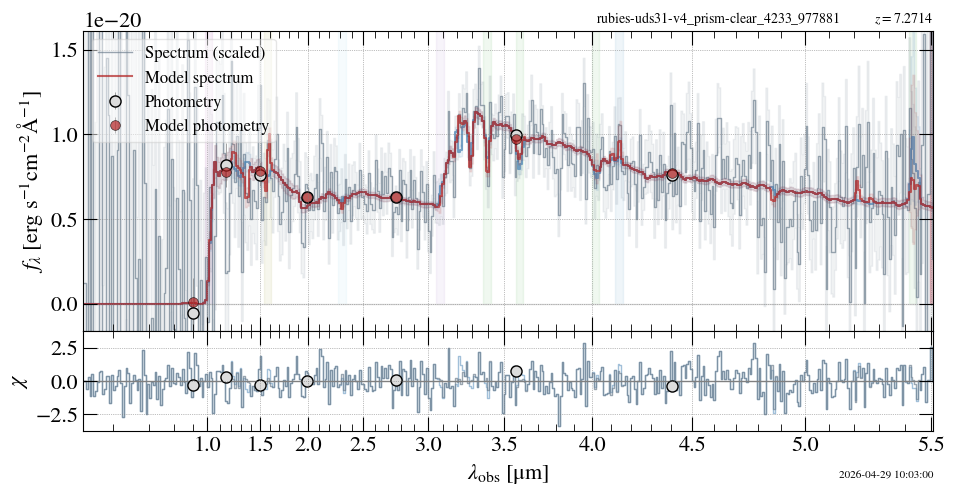

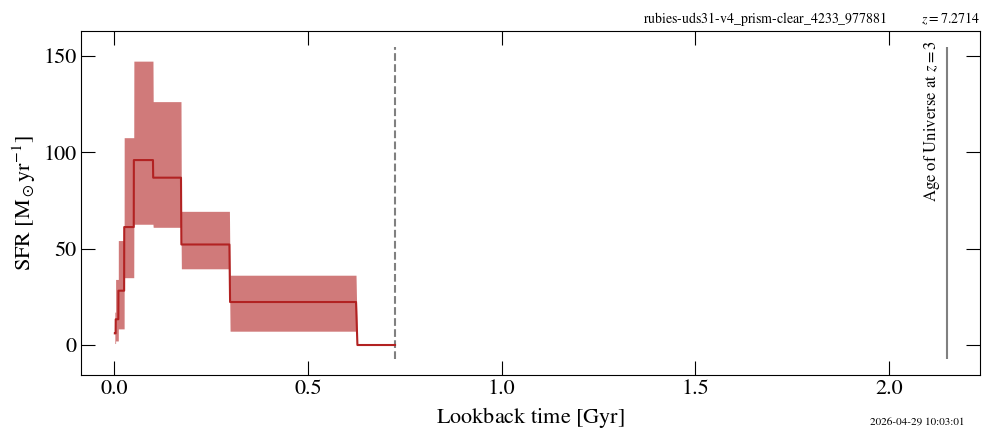

In [3]:
# ------- PLOTTING ------- #
import matplotlib.pyplot as plt

z_spec = djapipes.database.pull_zspec_from_db(fname) # pull spectroscopic redshift from database

djapipes.plotting.plot_fitted_spectrum(fit, fname_spec=fname, z_spec=z_spec, suffix=suffix, spec_only=spec_only, f_lam=True, save=False)
plt.show()

djapipes.plotting.plot_fitted_sfh(fit, fname_spec=fname, z_spec=z_spec, suffix=suffix, save=False)
plt.show()